# Reading plates

Behind every profile there are images and segmentations.
{func}`~mantispy.io.read_plate` reads one plate of them into a {class}`~spatialdata.SpatialData` object: fields of view as Images, the CellProfiler objects as Labels, the wells as Shapes, and the well- and cell-level measurements as Tables that annotate them.

It reads two layouts and tells them apart by the contents of the directory you point it at:

- a Cell Painting Gallery source {cite:p}`Weisbart_2024`, the `images/` and `workspace/` trees of an accession;
- a CellProfiler export, the folder the `ExportForSpatialData` module writes out of a pipeline run.

This tutorial uses a synthetic plate, so nothing has to be downloaded first.

In [1]:
import matplotlib.pyplot as plt
import numpy as np

import mantispy as mt

sdata = mt.ds.blobs(n_wells=4, n_sites=4)
sdata

/Users/tim.treis/Documents/GitHub/mantispy/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


SpatialData object
├── Images
│     ├── 'BLOBS01_A01_s1_image': DataArray[cyx] (5, 64, 64)
│     ├── 'BLOBS01_A01_s2_image': DataArray[cyx] (5, 64, 64)
│     ├── 'BLOBS01_A01_s3_image': DataArray[cyx] (5, 64, 64)
│     ├── 'BLOBS01_A01_s4_image': DataArray[cyx] (5, 64, 64)
│     ├── 'BLOBS01_A02_s1_image': DataArray[cyx] (5, 64, 64)
│     ├── 'BLOBS01_A02_s2_image': DataArray[cyx] (5, 64, 64)
│     ├── 'BLOBS01_A02_s3_image': DataArray[cyx] (5, 64, 64)
│     ├── 'BLOBS01_A02_s4_image': DataArray[cyx] (5, 64, 64)
│     ├── 'BLOBS01_A03_s1_image': DataArray[cyx] (5, 64, 64)
│     ├── 'BLOBS01_A03_s2_image': DataArray[cyx] (5, 64, 64)
│     ├── 'BLOBS01_A03_s3_image': DataArray[cyx] (5, 64, 64)
│     ├── 'BLOBS01_A03_s4_image': DataArray[cyx] (5, 64, 64)
│     ├── 'BLOBS01_A04_s1_image': DataArray[cyx] (5, 64, 64)
│     ├── 'BLOBS01_A04_s2_image': DataArray[cyx] (5, 64, 64)
│     ├── 'BLOBS01_A04_s3_image': DataArray[cyx] (5, 64, 64)
│     └── 'BLOBS01_A04_s4_image': DataArray[cyx] (5, 64

## Coordinate systems

Every element sits in three coordinate systems: its own field, its well, and the plate.
This lays the fields of a well out as a mosaic and the wells as a plate map, with nothing resampled.

In [2]:
sorted(sdata.coordinate_systems)[:6]

['BLOBS01',
 'BLOBS01_A01',
 'BLOBS01_A01_s1',
 'BLOBS01_A01_s2',
 'BLOBS01_A01_s3',
 'BLOBS01_A01_s4']

Rendering a well in its own frame puts its four fields where the microscope stage found them:

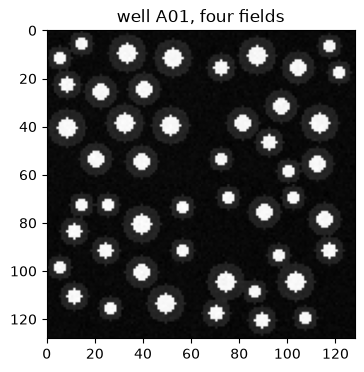

In [3]:
from spatialdata.transformations import get_transformation

fig, ax = plt.subplots(figsize=(4, 4))
for name, image in sdata.images.items():
    if "_A01_" not in name:
        continue
    offset = get_transformation(image, "BLOBS01_A01").to_affine_matrix(input_axes=("y", "x"), output_axes=("y", "x"))
    y, x = offset[0, 2], offset[1, 2]
    ax.imshow(np.asarray(image.sel(c="DNA")), extent=(x, x + 64, y + 64, y), cmap="gray")
ax.set(xlim=(0, 128), ylim=(128, 0), title="well A01, four fields")
plt.show()

## Images and labels

The image of a field carries one channel per stain, named.
The labels carry CellProfiler object numbers, so the rows of the cell table join straight onto them.

In [4]:
image = sdata["BLOBS01_A01_s1_image"]
list(image.coords["c"].values)

[np.str_('DNA'),
 np.str_('RNA'),
 np.str_('AGP'),
 np.str_('ER'),
 np.str_('Mito')]

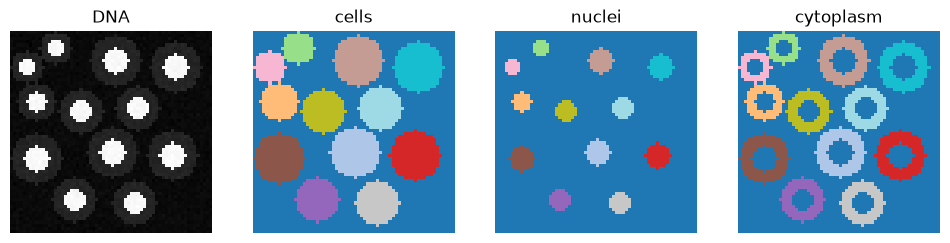

In [5]:
fig, axes = plt.subplots(1, 4, figsize=(12, 3))
axes[0].imshow(np.asarray(image.sel(c="DNA")), cmap="gray")
axes[0].set_title("DNA")
for ax, name in zip(axes[1:], ("cells", "nuclei", "cytoplasm"), strict=True):
    ax.imshow(np.asarray(sdata[f"BLOBS01_A01_s1_{name}"]), cmap="tab20")
    ax.set_title(name)
for ax in axes:
    ax.set_axis_off()
plt.show()

Cytoplasm is the cell mask minus the nucleus mask, as CellProfiler defines it.

## The tables

`cells` holds one row per segmented object and `wells` one row per well.
Both are ordinary {class}`~anndata.AnnData` objects.
Their `var` is annotated with what each feature name encodes, as {func}`~mantispy.io.read_profiles` annotates a profile read from disk.

In [6]:
cells = sdata.tables["cells"]
cells

AnnData object with n_obs × n_vars = 192 × 19
    obs: 'Metadata_Plate', 'Metadata_Well', 'Metadata_Site', 'Metadata_ObjectNumber', 'region'
    var: 'object', 'feature_group', 'feature', 'channel', 'scale', 'angle', 'gray_levels', 'radial_bin', 'params', 'is_feature'
    uns: 'mantispy', 'spatialdata_attrs'
    layers: None (.X)

In [7]:
cells.var

,object,feature_group,feature,channel,scale,angle,gray_levels,radial_bin,params,is_feature
Cells_AreaShape_Area,Cells,AreaShape,Area,NaN,NaN,NaN,NaN,NaN,NaN,True
Cells_Intensity_MeanIntensity_DNA,Cells,Intensity,MeanIntensity,DNA,NaN,NaN,NaN,NaN,NaN,True
Cells_Intensity_MeanIntensity_RNA,Cells,Intensity,MeanIntensity,RNA,NaN,NaN,NaN,NaN,NaN,True
Cells_Intensity_MeanIntensity_AGP,Cells,Intensity,MeanIntensity,AGP,NaN,NaN,NaN,NaN,NaN,True
Cells_Intensity_MeanIntensity_ER,Cells,Intensity,MeanIntensity,ER,NaN,NaN,NaN,NaN,NaN,True
Cells_Intensity_MeanIntensity_Mito,Cells,Intensity,MeanIntensity,Mito,NaN,NaN,NaN,NaN,NaN,True
Nuclei_AreaShape_Area,Nuclei,AreaShape,Area,NaN,NaN,NaN,NaN,NaN,NaN,True
Nuclei_Intensity_MeanIntensity_DNA,Nuclei,Intensity,MeanIntensity,DNA,NaN,NaN,NaN,NaN,NaN,True
Nuclei_Intensity_MeanIntensity_RNA,Nuclei,Intensity,MeanIntensity,RNA,NaN,NaN,NaN,NaN,NaN,True
Nuclei_Intensity_MeanIntensity_AGP,Nuclei,Intensity,MeanIntensity,AGP,NaN,NaN,NaN,NaN,NaN,True


`region` names the Labels element each row annotates, and `Metadata_ObjectNumber` the label value inside it:

In [8]:
cells.obs.head()

,Metadata_Plate,Metadata_Well,Metadata_Site,Metadata_ObjectNumber,region
BLOBS01_A01_s1_cells:1,BLOBS01,A01,1,1,BLOBS01_A01_s1_cells
BLOBS01_A01_s1_cells:2,BLOBS01,A01,1,2,BLOBS01_A01_s1_cells
BLOBS01_A01_s1_cells:3,BLOBS01,A01,1,3,BLOBS01_A01_s1_cells
BLOBS01_A01_s1_cells:4,BLOBS01,A01,1,4,BLOBS01_A01_s1_cells
BLOBS01_A01_s1_cells:5,BLOBS01,A01,1,5,BLOBS01_A01_s1_cells


## Reading a real plate

A gallery source needs the accession directory, the batch and the plate barcode:

```python
sdata = mt.io.read_plate(
    "cpg0000-jump-pilot/source_4",
    "BR00116991",
    batch="2020_11_04_CPJUMP1",
    wells=["A01"],
)
```

`wells` defaults to every well whose images are present, so a partial download reads back as itself.
The gallery publishes one-pixel object outlines rather than segmentation masks, so the Labels are reconstructed from them.
A component is accepted only when exactly one object centroid falls in it and its area is close to the area CellProfiler measured.
Rows whose object was not reconstructed are dropped.
Every label therefore stands for one object.

Where a source recorded no stage coordinates, or no pixel size to convert them with, each field sits in its own frame.
{func}`~mantispy.io.read_plate` then keeps that layout instead of inventing one, and leaves out the well shapes and the plate frame they would have lived in.

A plate straight out of a pipeline run needs only its folder:

```python
sdata = mt.io.read_plate("run_export/Plate1")
```

Nothing is reconstructed on that path.
The `ExportForSpatialData` module writes real label arrays, a per-cell table already joined across compartments, and a manifest in the table's `uns` listing what it wrote.
The reader builds only what the manifest names, so a folder that was moved still reads.
Arrays a failed cycle never wrote are skipped, together with the rows that annotate them.

## Two plates

Element names carry the plate barcode, so two plates concatenate without renaming:

In [9]:
import spatialdata as sd

other = mt.ds.blobs(n_wells=4, n_sites=4, plate="BLOBS02", seed=1)
merged = sd.concatenate([sdata, other], concatenate_tables=True)
merged.tables["wells"].obs.groupby("Metadata_Plate", observed=True).size()

Metadata_Plate
BLOBS01    4
BLOBS02    4
dtype: int64